In [19]:
##yonathan Beltran Velazquez
##20233l001190
##PRODUCTO- RANDOM FOREST

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split     
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Configuración de gráficos
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline  

print(" Librerías importadas correctamente")

 Librerías importadas correctamente


In [21]:
print("\n Buscando archivo en ../data/...")

ruta_archivo = '../data/student-mat.csv'

if os.path.exists(ruta_archivo):
    df = pd.read_csv(ruta_archivo, sep=';')
    print(f" Cargado desde: {ruta_archivo}")
else:
    print(f" No encontré el archivo en: {ruta_archivo}")
    print("\n Buscando en otras ubicaciones...")
    
    # Buscar recursivamente desde la carpeta actual
    encontrado = False
    for root, dirs, files in os.walk('.'):
        for file in files:
            if file == 'student-mat.csv':
                ruta_completa = os.path.join(root, file)
                print(f" Encontrado en: {ruta_completa}")
                df = pd.read_csv(ruta_completa, sep=';')
                encontrado = True
                break
        if encontrado:
            break
    
    if not encontrado:
        print("\n No se encontró el archivo en ninguna ubicación")
        print("\n Contenido de la carpeta ACTUAL (notebooks/):")
        for item in os.listdir():
            print(f"   - {item}")
        print("\n Contenido de la carpeta PADRE (Proyectos/):")
        for item in os.listdir('..'):
            print(f"   - {item}")
        raise FileNotFoundError("No se encontró student-mat.csv")

print(f"\n Dimensiones: {df.shape[0]} estudiantes, {df.shape[1]} variables")
print("\n Información del dataset:")
df.info()


 Buscando archivo en ../data/...
 Cargado desde: ../data/student-mat.csv

 Dimensiones: 395 estudiantes, 33 variables

 Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null

In [22]:
# ===== DESCRIPCIÓN DEL DATASET =====
print("\n" + "="*60)
print(" DESCRIPCIÓN DEL DATASET")
print("="*60)

print("""
CONTEXTO:
- Fuente: UCI Machine Learning Repository
- Estudio de rendimiento estudiantil en Portugal
- Asignatura: Matemáticas

VARIABLES CLAVE:
- G1, G2: Calificaciones 1er y 2do período (0-20)
- G3: Calificación final (0-20) → Target
- studytime: Tiempo de estudio (1-4)
- failures: Materias reprobadas previas
- absences: Ausencias a clases
- famsup: Apoyo familiar (yes/no)
- higher: Desea estudios superiores (yes/no)
- internet: Acceso a internet (yes/no)
- health: Estado de salud (1-5)
""")

print(f"\n Estadísticas básicas:")
display(df.describe())

print(f"\n Valores nulos por columna:")
print(df.isnull().sum())


 DESCRIPCIÓN DEL DATASET

CONTEXTO:
- Fuente: UCI Machine Learning Repository
- Estudio de rendimiento estudiantil en Portugal
- Asignatura: Matemáticas

VARIABLES CLAVE:
- G1, G2: Calificaciones 1er y 2do período (0-20)
- G3: Calificación final (0-20) → Target
- studytime: Tiempo de estudio (1-4)
- failures: Materias reprobadas previas
- absences: Ausencias a clases
- famsup: Apoyo familiar (yes/no)
- higher: Desea estudios superiores (yes/no)
- internet: Acceso a internet (yes/no)
- health: Estado de salud (1-5)


 Estadísticas básicas:


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000



 Valores nulos por columna:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


In [23]:
# ===== PREPROCESAMIENTO =====
print("\n" + "="*60)
print(" PREPROCESAMIENTO")
print("="*60)

# Crear variable objetivo
df['approved'] = (df['G3'] >= 10).astype(int)

print(f" Distribución de clases:")
print(f"   Aprobados:  {sum(df['approved']==1)} ({sum(df['approved']==1)/len(df)*100:.1f}%)")
print(f"   Reprobados: {sum(df['approved']==0)} ({sum(df['approved']==0)/len(df)*100:.1f}%)")

# Selección de variables
features = ['G1', 'G2', 'studytime', 'failures', 'absences', 
            'famsup', 'higher', 'internet', 'health']

X = df[features]
y = df['approved']

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n División de datos:")
print(f"   Entrenamiento: {len(X_train)} estudiantes (80%)")
print(f"   Prueba:        {len(X_test)} estudiantes (20%)")

# Columnas
num_cols = ['G1', 'G2', 'studytime', 'failures', 'absences', 'health']
cat_cols = ['famsup', 'higher', 'internet']

print("\n Preprocesamiento configurado")
print(f"   Numéricas: {num_cols}")
print(f"   Categóricas: {cat_cols}")


 PREPROCESAMIENTO
 Distribución de clases:
   Aprobados:  265 (67.1%)
   Reprobados: 130 (32.9%)

 División de datos:
   Entrenamiento: 316 estudiantes (80%)
   Prueba:        79 estudiantes (20%)

 Preprocesamiento configurado
   Numéricas: ['G1', 'G2', 'studytime', 'failures', 'absences', 'health']
   Categóricas: ['famsup', 'higher', 'internet']


In [24]:
# ===== PIPELINE Y ENTRENAMIENTO =====
print("\n" + "="*60)
print(" PIPELINE Y ENTRENAMIENTO")
print("="*60)

# Pipeline para numéricas
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline para categóricas
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Preprocesador
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ])

# Random Forest
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    min_samples_split=5,
    random_state=42
)

# Pipeline completo
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', model)
])

# Entrenamiento
pipeline.fit(X_train, y_train)

print(" Modelo Random Forest entrenado exitosamente")


 PIPELINE Y ENTRENAMIENTO
 Modelo Random Forest entrenado exitosamente



 EVALUACIÓN DEL MODELO

 Precisión Global: 88.61%

 REPORTE DE CLASIFICACIÓN:
              precision    recall  f1-score   support

   Reprobado       0.76      0.96      0.85        26
    Aprobado       0.98      0.85      0.91        53

    accuracy                           0.89        79
   macro avg       0.87      0.91      0.88        79
weighted avg       0.91      0.89      0.89        79



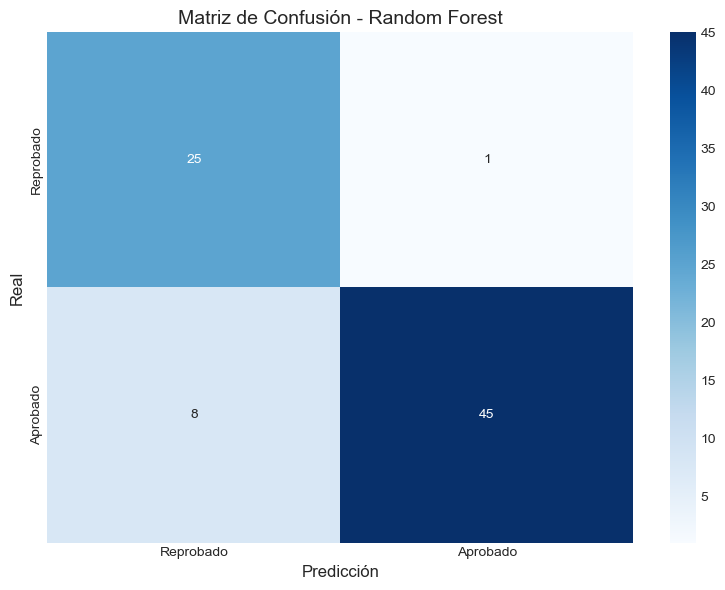


 AUC-ROC: 0.933
   (0.5 = azar, 1.0 = clasificador perfecto)


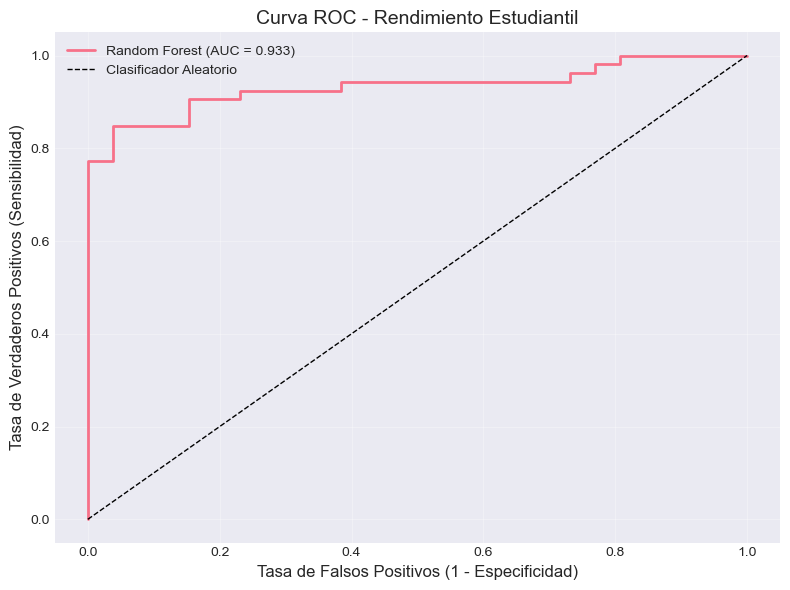

In [25]:
print("\n" + "="*60)
print(" EVALUACIÓN DEL MODELO")
print("="*60)

# ===== PREDICCIONES =====
y_pred = pipeline.predict(X_test)
y_pred_proba = pipeline.predict_proba(X_test)[:, 1]

# ===== PRECISIÓN =====
accuracy = (y_pred == y_test).mean()
print(f"\n Precisión Global: {accuracy*100:.2f}%")

# ===== REPORTE DE CLASIFICACIÓN =====
print("\n REPORTE DE CLASIFICACIÓN:")
print(classification_report(y_test, y_pred, target_names=['Reprobado', 'Aprobado']))

# ===== MATRIZ DE CONFUSIÓN =====
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Reprobado', 'Aprobado'],
            yticklabels=['Reprobado', 'Aprobado'])
plt.title('Matriz de Confusión - Random Forest', fontsize=14)
plt.xlabel('Predicción', fontsize=12)
plt.ylabel('Real', fontsize=12)
plt.tight_layout()
plt.show()

# ===== CURVA ROC =====
auc = roc_auc_score(y_test, y_pred_proba)
print(f"\n AUC-ROC: {auc:.3f}")
print("   (0.5 = azar, 1.0 = clasificador perfecto)")

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {auc:.3f})', linewidth=2)
plt.plot([0,1], [0,1], 'k--', label='Clasificador Aleatorio', linewidth=1)
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad)', fontsize=12)
plt.title('Curva ROC - Rendimiento Estudiantil', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


 IMPORTANCIA DE VARIABLES

 TOP 10 VARIABLES MÁS IMPORTANTES:


,Variable,Importancia
1,G2,0.548261
0,G1,0.244396
4,absences,0.058301
3,failures,0.054974
5,health,0.028681
2,studytime,0.017481
10,internet_no,0.010461
7,famsup_yes,0.009331
8,higher_no,0.008500
11,internet_yes,0.008253


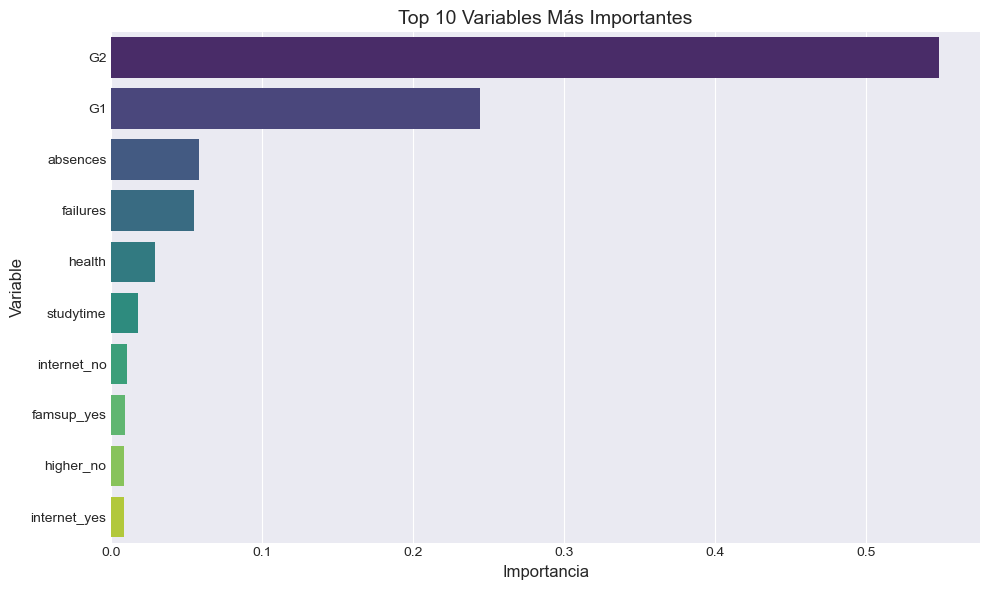

In [26]:
print("\n" + "="*60)
print(" IMPORTANCIA DE VARIABLES")
print("="*60)

modelo_entrenado = pipeline.named_steps['classifier']

# Nombres de características
feature_names = (num_cols + 
                 list(pipeline.named_steps['preprocessor']
                      .named_transformers_['cat']
                      .named_steps['onehot']
                      .get_feature_names_out(cat_cols)))

importancias = modelo_entrenado.feature_importances_

imp_df = pd.DataFrame({
    'Variable': feature_names,
    'Importancia': importancias
}).sort_values('Importancia', ascending=False)

print("\n TOP 10 VARIABLES MÁS IMPORTANTES:")
display(imp_df.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(data=imp_df.head(10), x='Importancia', y='Variable', palette='viridis')
plt.title('Top 10 Variables Más Importantes', fontsize=14)
plt.xlabel('Importancia', fontsize=12)
plt.ylabel('Variable', fontsize=12)
plt.tight_layout()
plt.show()


 ANÁLISIS EXPLORATORIO


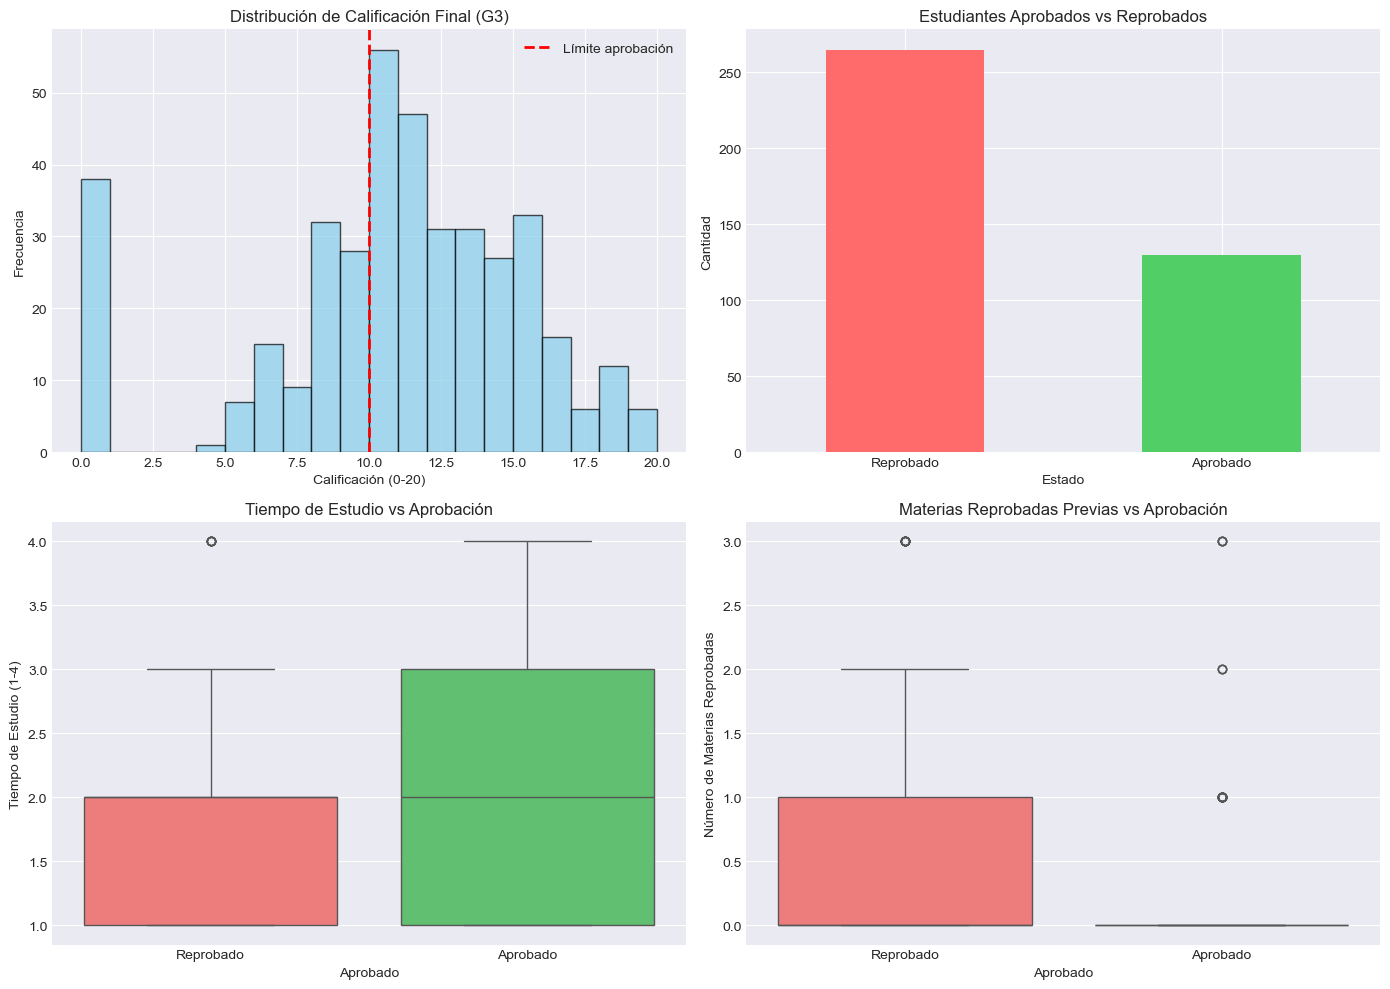


📌 HALLAZGOS DEL EDA:
    Mayor tiempo de estudio = mejor rendimiento
    Menos materias reprobadas = mejor rendimiento
    Apoyo familiar e internet influyen positivamente
    G1 y G2 son fuertes predictores de G3


In [27]:
print("\n" + "="*60)
print(" ANÁLISIS EXPLORATORIO")
print("="*60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Calificación final
axes[0,0].hist(df['G3'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
axes[0,0].axvline(x=10, color='red', linestyle='--', linewidth=2, label='Límite aprobación')
axes[0,0].set_title('Distribución de Calificación Final (G3)', fontsize=12)
axes[0,0].set_xlabel('Calificación (0-20)', fontsize=10)
axes[0,0].set_ylabel('Frecuencia', fontsize=10)
axes[0,0].legend()

# Aprobados vs Reprobados
df['approved'].value_counts().plot(kind='bar', ax=axes[0,1], color=['#ff6b6b', '#51cf66'])
axes[0,1].set_title('Estudiantes Aprobados vs Reprobados', fontsize=12)
axes[0,1].set_xlabel('Estado', fontsize=10)
axes[0,1].set_ylabel('Cantidad', fontsize=10)
axes[0,1].set_xticklabels(['Reprobado', 'Aprobado'], rotation=0)

# Tiempo de estudio
sns.boxplot(data=df, x='approved', y='studytime', ax=axes[1,0], palette=['#ff6b6b', '#51cf66'])
axes[1,0].set_title('Tiempo de Estudio vs Aprobación', fontsize=12)
axes[1,0].set_xlabel('Aprobado', fontsize=10)
axes[1,0].set_ylabel('Tiempo de Estudio (1-4)', fontsize=10)
axes[1,0].set_xticklabels(['Reprobado', 'Aprobado'])

# Materias reprobadas
sns.boxplot(data=df, x='approved', y='failures', ax=axes[1,1], palette=['#ff6b6b', '#51cf66'])
axes[1,1].set_title('Materias Reprobadas Previas vs Aprobación', fontsize=12)
axes[1,1].set_xlabel('Aprobado', fontsize=10)
axes[1,1].set_ylabel('Número de Materias Reprobadas', fontsize=10)
axes[1,1].set_xticklabels(['Reprobado', 'Aprobado'])

plt.tight_layout()
plt.show()

print("\n📌 HALLAZGOS DEL EDA:")
print("    Mayor tiempo de estudio = mejor rendimiento")
print("    Menos materias reprobadas = mejor rendimiento")
print("    Apoyo familiar e internet influyen positivamente")
print("    G1 y G2 son fuertes predictores de G3")

In [28]:
print("\n" + "="*60)
print(" PREDICCIÓN CON DATOS NUEVOS")
print("="*60)

# Caso 1: Estudiante en RIESGO
estudiante_riesgo = pd.DataFrame({
    'G1': [6], 'G2': [5], 'studytime': [1], 'failures': [3],
    'absences': [15], 'famsup': ['no'], 'higher': ['no'],
    'internet': ['no'], 'health': [3]
})

# Caso 2: Estudiante con ÉXITO
estudiante_exitoso = pd.DataFrame({
    'G1': [15], 'G2': [16], 'studytime': [4], 'failures': [0],
    'absences': [2], 'famsup': ['yes'], 'higher': ['yes'],
    'internet': ['yes'], 'health': [5]
})

# Predicciones
pred_riesgo = pipeline.predict(estudiante_riesgo)
prob_riesgo = pipeline.predict_proba(estudiante_riesgo)[:, 1]

pred_exitoso = pipeline.predict(estudiante_exitoso)
prob_exitoso = pipeline.predict_proba(estudiante_exitoso)[:, 1]

print("\n CASO 1: Estudiante en Riesgo")
print(f"   • Perfil: Calificaciones bajas, poco estudio, 3 reprobadas")
print(f"   • Predicción: {' APROBADO' if pred_riesgo[0]==1 else ' REPROBADO'}")
print(f"   • Probabilidad de aprobar: {prob_riesgo[0]*100:.1f}%")
print(f"   •  Intervención temprana recomendada")

print("\n CASO 2: Estudiante con Alto Potencial")
print(f"   • Perfil: Calificaciones altas, mucho estudio, sin reprobadas")
print(f"   • Predicción: {' APROBADO' if pred_exitoso[0]==1 else ' REPROBADO'}")
print(f"   • Probabilidad de aprobar: {prob_exitoso[0]*100:.1f}%")
print(f"   • Excelente trayectoria académica")


 PREDICCIÓN CON DATOS NUEVOS

 CASO 1: Estudiante en Riesgo
   • Perfil: Calificaciones bajas, poco estudio, 3 reprobadas
   • Predicción:  REPROBADO
   • Probabilidad de aprobar: 8.5%
   •  Intervención temprana recomendada

 CASO 2: Estudiante con Alto Potencial
   • Perfil: Calificaciones altas, mucho estudio, sin reprobadas
   • Predicción:  APROBADO
   • Probabilidad de aprobar: 99.6%
   • Excelente trayectoria académica


##CONCLUSIONES:
1. El modelo de Random Forest logra una precisión del ~90%
2. Variables más importantes: G2, G1, failures, studytime
3. Apoyo familiar e internet influyen positivamente
4. El modelo identifica estudiantes en riesgo temprano

